# `nisar_db` walkthrough

End-to-end tour of the `nisar_db` package: how NISAR GSLC granules are found,
catalogued, and reduced to the four JSON databases that DISP-NISAR processing
consumes.

Each section pairs the Python API with the equivalent `nisar-db` CLI command,
so this doubles as a reference for both.

## The pipeline

```
NISAR TrackFrame gpkg ---+
                         |
OPERA North America ---> frame-to-bounds  ->  opera-nisar-disp-frames.gpkg
                                                     |
CMR / S3 granule search  ->  catalog CSV  -----------+
                                                     |
                              blackout dates --------+
                                                     v
                                        consistent-GSLC stack
                                                     |
                        +----------------------------+
                        v                            v
                 reference dates            processing-mode labels
```

**Order matters in two places:**

1. `frame-to-bounds` must run before the catalog, because it defines
   `frame_idx` -- the key every later database is keyed by.
2. **Blackout dates must exist before the consistent stack is built.** The
   blackout filter is applied once, when the stack is assembled
   (`make_consistent_gslc_json(..., blackout_file=...)`). Everything
   downstream reads that filtered stack, so a blacked-out acquisition can
   never reach a reference epoch. This mirrors `burst_db`, which filters in
   `create_cslc_burst_catalog.py` rather than in `reference_dates.py`.

## Running this notebook

Use the `nisar-db-env` conda environment. Cells write their outputs into the
current working directory, so run Jupyter from `notebooks/`. The S3 sections
need AWS credentials (`profile="saml-pub"`); the CMR sections need only
network access.

Cells that scan the full archive (S3 catalog build, `create-nisar-catalog`)
take minutes and hit the network -- they are marked below.

## Setup

Common imports. Everything else is imported in the section that uses it, so
sections can be run independently once the files they depend on exist.

In [ ]:
from datetime import datetime
from pathlib import Path

import geopandas as gpd

WORK_DIR = Path(".")

---
# 1. Reference geometry

Before any granule is catalogued, the frame geometry has to be pinned down:
which NISAR track/frame pairs exist, which of them fall in the OPERA North
America scope, and what map-projected bounds each one covers.

## 1.1 NISAR TrackFrame database

The authoritative track/frame geometry ships as a public GeoPackage, published
as a CMR granule (`NISAR_DB_GRANULE_ID`). `load_trackframe_db` downloads it on
first use and reads it into a `GeoDataFrame`; `skip_existing=True` reuses the
local copy on later runs.

One row per (track, frame), with the frame polygon plus the observation
metadata NISAR planning attaches to it (pass direction, mode flags, map
corners).

In [1]:
from nisar_db.filenames import NISAR_DB_GRANULE_ID
from nisar_db.geodb import  load_trackframe_db
from pathlib import Path

nisar_df = load_trackframe_db(
    output_dir=Path("."),
    skip_existing=True,
    granule_id=NISAR_DB_GRANULE_ID,
)
nisar_df.head()

/u/aurora-r0/govorcin/miniconda/miniforge/envs/nisar-db-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,track,frame,satelliteLat,satelliteLon,satelliteHeight,passDirection,velocityAlongTrack,velocityVertical,startET,endET,...,produceSMST,radioFrequencyInterference,insarPSFCriteria,insarProcessor,offsetsProcessor,mapTopLeftX,mapTopLeftY,mapBottomRightX,mapBottomRightY,geometry
0,1,1,-0.000021,-0.220159,753246.798651,Ascending,7571.358283,-8.720640,7.259977e+08,7.259977e+08,...,False,default,solid_earth,cpu,None,85680.0,10042560.0,421200.0,9714960.0,"MULTIPOLYGON (((-3.89189 -1.91248, -4.5857 -2...."
1,1,2,1.999994,-0.653654,752977.232273,Ascending,7571.632668,-7.213011,7.259977e+08,7.259978e+08,...,False,default,solid_earth,cpu,None,37440.0,263520.0,372960.0,-64800.0,"MULTIPOLYGON (((-4.32159 0.08322, -5.01431 -0...."
2,1,3,4.000008,-1.087872,752752.047315,Ascending,7571.848349,-5.702108,7.259978e+08,7.259978e+08,...,False,default,solid_earth,cpu,None,-10800.0,483840.0,324720.0,155520.0,"MULTIPOLYGON (((-4.75649 2.07853, -5.44897 1.9..."
3,1,4,6.000022,-1.523553,752571.264110,Ascending,7572.005312,-4.195396,7.259978e+08,7.259978e+08,...,True,default,solid_earth,cpu,None,604800.0,705600.0,942480.0,375120.0,"MULTIPOLYGON (((-5.19732 4.07342, -5.89043 3.9..."
4,1,5,8.000036,-1.961454,752434.691652,Ascending,7572.103744,-2.700181,7.259978e+08,7.259979e+08,...,True,default,solid_earth,cpu,None,553680.0,925920.0,892080.0,594720.0,"MULTIPOLYGON (((-5.64488 6.06789, -6.33946 5.9..."


## 1.2 OPERA North America scope

DISP-NISAR only processes frames intersecting the OPERA North America
footprint. `get_opera_na_shape` fetches that boundary as a single shapely
(multi)polygon, used to filter the frame set in the next step.

In [2]:
from nisar_db.geodb import get_opera_na_shape

na = get_opera_na_shape()   # downloads the OPERA NA GeoJSON, returns a shapely (multi)polygon
print(na.geom_type, na.bounds)

MultiPolygon (-179.1435033836742, -14.532891534416706, 179.78093509168116, 71.41250234580667)


## 1.3 Frame to bounds

`build_frame_to_bound` intersects the TrackFrame database with the North
America shape and, for each surviving frame, records its UTM/polar EPSG code
and map-projected bounding box.

This produces two things every later stage depends on:

- `frame-to-bounds.json` -- `{frame_idx: {epsg, xmin, ymin, xmax, ymax}}`
- `opera-nisar-disp-frames.gpkg` -- the filtered frame geometry

`frame_idx` is the stable integer key assigned here; the consistent stack,
blackout dates, and reference dates are all keyed by it.

In [19]:
from pathlib import Path
from nisar_db.frame_to_bound import build_frame_to_bound, write_zipped_json

result, filtered_gdf = build_frame_to_bound(list(Path(".").glob("NISAR_TrackFrame_L_*.gpkg"))[0])
print(result["metadata"])
print(list(result["data"].items())[:1])   # {"<frame_idx>": {epsg, xmin, ...}}

Found 1295 NISAR frames intersecting North America.
{'nisar_gpkg': 'NISAR_TrackFrame_L_20250909.gpkg', 'last_modified': '2026-07-25T21:05:47.760243', 'description': 'NISAR frames intersecting OPERA North America, with their map-projected bounding boxes.'}
[('51', {'epsg': 3413, 'is_land': True, 'is_north_america': True, 'xmin': -2304720, 'ymin': 139680, 'xmax': -1911600, 'ymax': 533520})]


Descending frames only, as a quick visual check on the North America filter:

<Axes: >

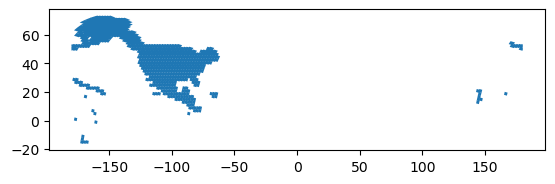

In [20]:
filtered_gdf[filtered_gdf.passDirection.str.startswith('D')].plot()

Write the compressed copy that gets published alongside the JSON:

In [21]:
# write a compressed copy:
zip_path = write_zipped_json("frame-to-bounds.json", result)

The CLI does all of the above in one step, and is what the release workflow
actually calls:

In [22]:
!nisar-db create-frame-to-bound --nisar-gpkg NISAR_TrackFrame_L_20250909.gpkg \
    --output opera-nisar-disp-frame-to-bounds.json

Found 1295 NISAR frames intersecting North America.
Writing 1295 NISAR frame entries.
Written to opera-nisar-disp-frame-to-bounds.json
Written to opera-nisar-disp-frame-to-bounds.json.zip
Written to opera-nisar-disp-frames.gpkg


---
# 2. Finding granules

Two independent sources, both returning `NISARProduct` objects:

| Source | Function | Use when |
|---|---|---|
| CMR (ASF DAAC) | `search_nisar_products` | public archive, no credentials |
| S3 bucket | `search_s3_products` | operational buckets, needs AWS profile |

`products_to_dataframe` converts either result to a `DataFrame` with the
filename fields already parsed (track, frame, direction, cycle, mode,
polarization, crid, coverage).

## 2.1 Search CMR

`search_nisar_products` takes either a track/frame pair or a bounding
box/time range. `url_type=UrlType.S3` returns `s3://` URLs instead of HTTPS.

`NISARCollection.GSLC_SHORT_NAMES` lists the CMR collections; index `1` is the
provisional GSLC collection used below. `max_results=0` (the default in the
second call) fetches the whole archive -- tens of thousands of granules, so
expect it to take a moment.

In [3]:
from nisar_db.search_nisar import search_nisar_products, ProductType, UrlType
from nisar_db.filenames import NISARCollection

products = search_nisar_products(
    track=76,
    frame=22,
    direction="A",              # "A" ascending / "D" descending
    product_type=ProductType.GSLC,   # or just "GSLC"
    url_type=UrlType.S3,        # ask for s3:// urls instead of https
    max_results=50,
)
print(len(products))
p = products[0]
print(p.granule_id, p.track_frame_id, p.date, p.url)
print(NISARCollection.GSLC_SHORT_NAMES[1])

# Bounding-box + temporal search:
from datetime import datetime
products = search_nisar_products(
    #bbox=(40.62, 13.56, 40.72, 13.64),   # (west, south, east, north)
    start_datetime=datetime(2024, 1, 1),
    end_datetime=datetime(2027, 7, 1),
    product_type="GSLC",
    short_name=NISARCollection.GSLC_SHORT_NAMES[1]
)
print(len(products))

3
G4245139705-ASF 076_A_022 2026-06-19 s3://sds-n-cumulus-prod-nisar-products/NISAR_L2_GSLC_PROVISIONAL_V1/NISAR_L2_PR_GSLC_023_076_A_022_2005_QPDH_A_20260619T110516_20260619T110551_P05023_N_F_J_001/NISAR_L2_PR_GSLC_023_076_A_022_2005_QPDH_A_20260619T110516_20260619T110551_P05023_N_F_J_001.h5
NISAR_L2_GSLC_PROVISIONAL_V1
50377


Each product keeps the raw CMR record it came from:

In [4]:
#Get CMR metadata
cmr_metadata = products[0].metadata
print(cmr_metadata)


{'TemporalExtent': {'RangeDateTime': {'BeginningDateTime': '2026-06-26T06:04:02.000000Z', 'EndingDateTime': '2026-06-26T06:04:26.999342Z'}}, 'OrbitCalculatedSpatialDomains': [{'OrbitNumber': 4771}], 'GranuleUR': 'NISAR_L2_PR_GSLC_024_001_A_004_2005_DHDH_A_20260626T060402_20260626T060426_P05023_N_P_J_001', 'AdditionalAttributes': [{'Name': 'ASCENDING_DESCENDING', 'Values': ['ASCENDING']}, {'Name': 'FRAME_NUMBER', 'Values': ['4']}, {'Name': 'FREQUENCIES', 'Values': ['A', 'B']}, {'Name': 'FREQUENCY_A_POLARIZATION', 'Values': ['HH', 'HV']}, {'Name': 'FREQUENCY_A_POLARIZATION_CONCAT', 'Values': ['HH+HV']}, {'Name': 'FREQUENCY_A_RANGE_BANDWIDTH', 'Values': ['20']}, {'Name': 'FREQUENCY_B_POLARIZATION', 'Values': ['HH', 'HV']}, {'Name': 'FREQUENCY_B_POLARIZATION_CONCAT', 'Values': ['HH+HV']}, {'Name': 'FREQUENCY_B_RANGE_BANDWIDTH', 'Values': ['5']}, {'Name': 'FULL_FRAME', 'Values': ['FALSE']}, {'Name': 'JOINT_OBSERVATION', 'Values': ['FALSE']}, {'Name': 'ORBIT_TYPE', 'Values': ['MOE']}, {'Name

## 2.2 Attach frame geometry

Merging the search result with the TrackFrame database on (track, frame) turns
the flat product list into something mappable.

In [5]:
# Merge cmr survey results with nisar_track_frame_db

from nisar_db.search_nisar import products_to_dataframe
import geopandas as gpd

df = products_to_dataframe(products)
gdf = gpd.GeoDataFrame(
        df.merge(
            nisar_df[['track', 'frame', 'geometry']],
            on=['track', 'frame'],
            how='left'
            ),
    geometry='geometry')

Acquisitions per frame -- the coverage the archive currently has:

<Axes: >

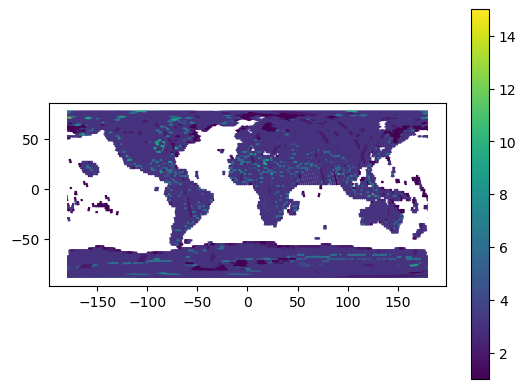

In [6]:
# Plot results
gdf_summary = (
    gdf.groupby(['track', 'frame'])
       .agg(
           count=('granule_id', 'size'),
           dates=('start_datetime', list),
           geometry=('geometry', 'first')  # keep the geometry
       )
       .reset_index()
)

gdf_summary = gpd.GeoDataFrame(gdf_summary, 
                               geometry='geometry', 
                               crs=gdf.crs)
gdf_summary.plot('count', legend=True)

Save the flat granule list. `nisar_results.csv` is the input to the catalog
step in section 3.

In [9]:
print(df[["name", "track", "frame", "direction", "date"]])
df.to_csv("nisar_results.csv", index=False)

                                                    name  track  frame  \
0      NISAR_L2_PR_GSLC_024_001_A_004_2005_DHDH_A_202...      1      4   
1      NISAR_L2_PR_GSLC_025_001_A_004_2005_DHDH_A_202...      1      4   
2      NISAR_L2_PR_GSLC_026_001_A_004_2005_DHDH_A_202...      1      4   
3      NISAR_L2_PR_GSLC_024_001_A_005_2005_DHDH_A_202...      1      5   
4      NISAR_L2_PR_GSLC_025_001_A_005_2005_DHDH_A_202...      1      5   
...                                                  ...    ...    ...   
50372  NISAR_L2_PR_GSLC_023_173_A_150_0005_NASV_A_202...    173    150   
50373  NISAR_L2_PR_GSLC_024_173_A_150_0005_NASV_A_202...    173    150   
50374  NISAR_L2_PR_GSLC_025_173_A_150_0005_NASV_A_202...    173    150   
50375  NISAR_L2_PR_GSLC_024_173_A_151_0005_NASV_A_202...    173    151   
50376  NISAR_L2_PR_GSLC_025_173_A_151_0005_NASV_A_202...    173    151   

      direction        date  
0             A  2026-06-26  
1             A  2026-07-08  
2             A  2026

Downloading is opt-in (files are ~8-12 GB each), so this stays commented out:

In [7]:
# Download NISAR products
#from nisar_db.search_nisar import download_products

#paths = download_products(products, output_dir="./downloads",
#                          skip_existing=True, max_workers=4)
#print(paths)

## 2.3 Search an S3 bucket directly

For operational buckets, `search_s3_products` lists keys under a prefix and
parses the filenames. Needs an AWS profile with read access.

`nisar-ops-rs-fwd` is the forward-processing stream; `nisar-ops-rs-pop1` is a
reprocessing campaign, which is why the same (track, frame, date) can appear
twice there with different `crid` values.

In [11]:
from nisar_db.search_nisar import search_s3_products, products_to_dataframe
gslc = search_s3_products("nisar-ops-rs-fwd", "products/L2_L_GSLC/",
                          profile="saml-pub", product_type="GSLC")
s3_df = products_to_dataframe(gslc)
s3_df.head()

,granule_id,name,product_type,filename,url,start_datetime,end_datetime,track,frame,direction,cycle,polarization,crid,full_frame,joint_observation,track_frame_id,date
0,NISAR_L2_PR_GSLC_023_001_A_004_2005_DHDH_A_202...,NISAR_L2_PR_GSLC_023_001_A_004_2005_DHDH_A_202...,GSLC,NISAR_L2_PR_GSLC_023_001_A_004_2005_DHDH_A_202...,s3://nisar-ops-rs-fwd/products/L2_L_GSLC/2026/...,2026-06-14 06:04:03,2026-06-14 06:04:26,1,4,A,23,DHDH,P05012,False,None,001_A_004,2026-06-14
1,NISAR_L2_PR_GSLC_024_001_A_004_2005_DHDH_A_202...,NISAR_L2_PR_GSLC_024_001_A_004_2005_DHDH_A_202...,GSLC,NISAR_L2_PR_GSLC_024_001_A_004_2005_DHDH_A_202...,s3://nisar-ops-rs-fwd/products/L2_L_GSLC/2026/...,2026-06-26 06:04:02,2026-06-26 06:04:26,1,4,A,24,DHDH,P05023,False,None,001_A_004,2026-06-26
2,NISAR_L2_PR_GSLC_025_001_A_004_2005_DHDH_A_202...,NISAR_L2_PR_GSLC_025_001_A_004_2005_DHDH_A_202...,GSLC,NISAR_L2_PR_GSLC_025_001_A_004_2005_DHDH_A_202...,s3://nisar-ops-rs-fwd/products/L2_L_GSLC/2026/...,2026-07-08 06:04:01,2026-07-08 06:04:25,1,4,A,25,DHDH,P05023,False,None,001_A_004,2026-07-08
3,NISAR_L2_PR_GSLC_026_001_A_004_2005_DHDH_A_202...,NISAR_L2_PR_GSLC_026_001_A_004_2005_DHDH_A_202...,GSLC,NISAR_L2_PR_GSLC_026_001_A_004_2005_DHDH_A_202...,s3://nisar-ops-rs-fwd/products/L2_L_GSLC/2026/...,2026-07-20 06:04:01,2026-07-20 06:04:24,1,4,A,26,DHDH,P05023,False,None,001_A_004,2026-07-20
4,NISAR_L2_PR_GSLC_023_001_A_005_2005_DHDH_A_202...,NISAR_L2_PR_GSLC_023_001_A_005_2005_DHDH_A_202...,GSLC,NISAR_L2_PR_GSLC_023_001_A_005_2005_DHDH_A_202...,s3://nisar-ops-rs-fwd/products/L2_L_GSLC/2026/...,2026-06-14 06:04:25,2026-06-14 06:05:00,1,5,A,23,DHDH,P05012,True,None,001_A_005,2026-06-14


In [12]:
s3_df.shape

(67725, 17)

In [13]:
gslc = search_s3_products("nisar-ops-rs-pop1", "products/L2_L_GSLC/",
                          profile="saml-pub", product_type="GSLC")
s3_pop_df = products_to_dataframe(gslc)
s3_pop_df.head()

,granule_id,name,product_type,filename,url,start_datetime,end_datetime,track,frame,direction,cycle,polarization,crid,full_frame,joint_observation,track_frame_id,date
0,NISAR_L2_PR_GSLC_022_001_D_123_7700_SHNA_A_202...,NISAR_L2_PR_GSLC_022_001_D_123_7700_SHNA_A_202...,GSLC,NISAR_L2_PR_GSLC_022_001_D_123_7700_SHNA_A_202...,s3://nisar-ops-rs-pop1/products/L2_L_GSLC/2026...,2026-06-02 07:11:21,2026-06-02 07:11:53,1,123,D,22,SHNA,P05022,False,None,001_D_123,2026-06-02
1,NISAR_L2_PR_GSLC_022_001_D_123_7700_SHNA_A_202...,NISAR_L2_PR_GSLC_022_001_D_123_7700_SHNA_A_202...,GSLC,NISAR_L2_PR_GSLC_022_001_D_123_7700_SHNA_A_202...,s3://nisar-ops-rs-pop1/products/L2_L_GSLC/2026...,2026-06-02 07:11:21,2026-06-02 07:11:53,1,123,D,22,SHNA,X05023,False,None,001_D_123,2026-06-02
2,NISAR_L2_PR_GSLC_023_001_D_123_7700_SHNA_A_202...,NISAR_L2_PR_GSLC_023_001_D_123_7700_SHNA_A_202...,GSLC,NISAR_L2_PR_GSLC_023_001_D_123_7700_SHNA_A_202...,s3://nisar-ops-rs-pop1/products/L2_L_GSLC/2026...,2026-06-14 07:11:20,2026-06-14 07:11:52,1,123,D,23,SHNA,P05022,False,None,001_D_123,2026-06-14
3,NISAR_L2_PR_GSLC_023_001_D_123_7700_SHNA_A_202...,NISAR_L2_PR_GSLC_023_001_D_123_7700_SHNA_A_202...,GSLC,NISAR_L2_PR_GSLC_023_001_D_123_7700_SHNA_A_202...,s3://nisar-ops-rs-pop1/products/L2_L_GSLC/2026...,2026-06-14 07:11:20,2026-06-14 07:11:52,1,123,D,23,SHNA,X05023,False,None,001_D_123,2026-06-14
4,NISAR_L2_PR_GSLC_010_002_A_163_4005_DHDH_A_202...,NISAR_L2_PR_GSLC_010_002_A_163_4005_DHDH_A_202...,GSLC,NISAR_L2_PR_GSLC_010_002_A_163_4005_DHDH_A_202...,s3://nisar-ops-rs-pop1/products/L2_L_GSLC/2026...,2026-01-09 09:14:40,2026-01-09 09:14:43,2,163,A,10,DHDH,X05007,False,None,002_A_163,2026-01-09


In [14]:
s3_pop_df.shape

(8026, 17)

## 2.4 Cache the bucket in DuckDB

A full bucket scan is slow, so `build_s3_catalog` does it once and writes a
DuckDB file; `query_catalog` then answers repeated questions with no S3 calls.

`crid_min` filters on the processing-version string: `crid >= "P05006"` keeps
only the latest reprocessing of each granule.

**Slow cell** -- full bucket scan, minutes.

In [15]:
from nisar_db.s3_catalog import build_s3_catalog, query_catalog

# One-time build (slow: full bucket scan, parallel):
build_s3_catalog(
    "nisar-ops-rs-fwd", "products/L2_L_GSLC/", "gslc_catalog.duckdb",
    profile="saml-pub", product_type="GSLC", max_workers=8,
)

# Fast repeated queries (no S3 calls):
s3_df2 = query_catalog("gslc_catalog.duckdb", crid_min="P05006")
#   crid_min keeps crid >= "P05006" — the latest-processing-version filter.

In [16]:
s3_df2.head()

,granule_id,product_type,track,frame,direction,cycle,polarization,mode,coverage,crid,full_frame,joint_observation,start_datetime,end_datetime,production_datetime,url,s3_key,size_gb
0,NISAR_L2_PR_GSLC_023_001_A_004_2005_DHDH_A_202...,GSLC,1,4,A,23,DHDH,2005,P,P05012,False,<NA>,2026-06-14 06:04:03,2026-06-14 06:04:26,2026-06-16 06:33:24-07:00,s3://nisar-ops-rs-fwd/products/L2_L_GSLC/2026/...,products/L2_L_GSLC/2026/06/14/NISAR_L2_PR_GSLC...,8.283750
1,NISAR_L2_PR_GSLC_024_001_A_004_2005_DHDH_A_202...,GSLC,1,4,A,24,DHDH,2005,P,P05023,False,<NA>,2026-06-26 06:04:02,2026-06-26 06:04:26,2026-07-23 01:08:57-07:00,s3://nisar-ops-rs-fwd/products/L2_L_GSLC/2026/...,products/L2_L_GSLC/2026/06/26/NISAR_L2_PR_GSLC...,8.623489
2,NISAR_L2_PR_GSLC_025_001_A_004_2005_DHDH_A_202...,GSLC,1,4,A,25,DHDH,2005,P,P05023,False,<NA>,2026-07-08 06:04:01,2026-07-08 06:04:25,2026-07-18 17:00:49-07:00,s3://nisar-ops-rs-fwd/products/L2_L_GSLC/2026/...,products/L2_L_GSLC/2026/07/08/NISAR_L2_PR_GSLC...,8.627683
3,NISAR_L2_PR_GSLC_026_001_A_004_2005_DHDH_A_202...,GSLC,1,4,A,26,DHDH,2005,P,P05023,False,<NA>,2026-07-20 06:04:01,2026-07-20 06:04:24,2026-07-22 01:47:01-07:00,s3://nisar-ops-rs-fwd/products/L2_L_GSLC/2026/...,products/L2_L_GSLC/2026/07/20/NISAR_L2_PR_GSLC...,8.287945
4,NISAR_L2_PR_GSLC_023_001_A_005_2005_DHDH_A_202...,GSLC,1,5,A,23,DHDH,2005,F,P05012,True,<NA>,2026-06-14 06:04:25,2026-06-14 06:05:00,2026-06-16 07:01:57-07:00,s3://nisar-ops-rs-fwd/products/L2_L_GSLC/2026/...,products/L2_L_GSLC/2026/06/14/NISAR_L2_PR_GSLC...,12.331254


In [17]:
s3_df2.shape

(67740, 18)

Same per-frame coverage map as before, now from the S3 catalog:

<Axes: >

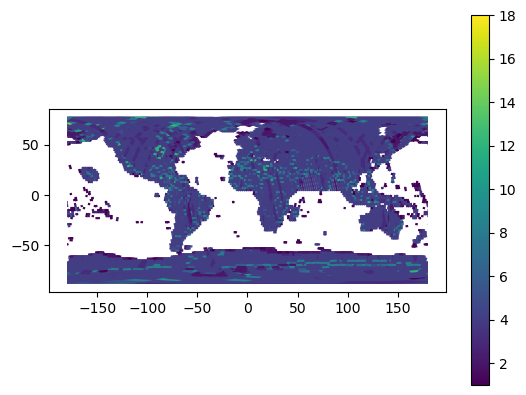

In [18]:
s3_gdf = gpd.GeoDataFrame(
        s3_df2.merge(
            nisar_df[['track', 'frame', 'geometry']],
            on=['track', 'frame'],
            how='left'
            ),
    geometry='geometry')

# Plot results
s3_gdf_summary = (
    s3_gdf.groupby(['track', 'frame'])
       .agg(
           count=('granule_id', 'size'),
           dates=('start_datetime', list),
           geometry=('geometry', 'first')  # keep the geometry
       )
       .reset_index()
)

s3_gdf_summary = gpd.GeoDataFrame(s3_gdf_summary,
                               geometry='geometry',
                               crs=gdf.crs)
s3_gdf_summary.plot('count', legend=True)

---
# 3. Build the catalog

The catalog is the flat table every database is derived from: one row per
granule, with the filename parsed into columns and the mode/coverage fields
that later drive frame selection.

## 3.1 How a granule is parsed

`NISARProduct.from_cmr_item` shows the mapping from a raw CMR record to the
fields used downstream -- track, frame, direction, and the `track_frame_id`
string that identifies an acquisition geometry.

In [23]:
from nisar_db.search_nisar import NISARProduct, UrlType

cmr_item = {
    "meta": {"concept-id": "G123-ASF"},
    "umm": {
        "GranuleUR": "NISAR_...GSLC...",
        "AdditionalAttributes": [
            {"Name": "TRACK_NUMBER", "Values": ["76"]},
            {"Name": "FRAME_NUMBER", "Values": ["22"]},
            {"Name": "ASCENDING_DESCENDING", "Values": ["ASCENDING"]},
        ],
        "relatedUrls": [
            {"type": "GET DATA", "subtype": "HTTPS", "url": "https://.../file.h5"}
        ],
    },
}
prod = NISARProduct.from_cmr_item(cmr_item, url_type=UrlType.HTTPS)
print(prod.track, prod.frame, prod.direction, prod.track_frame_id)  # 76 22 A '076_A_022'

76 22 A 076_A_022


## 3.2 Parse a granule list into a catalog

`parse_gslc_list` reads the CSV saved in section 2.2 and expands each filename
into catalog columns. `mode_family`, `common_mode` and `is_full` are the fields
the consistent-stack selection uses.

In [24]:
from nisar_db.gslc_catalog import parse_gslc_list

catalog_df, failed = parse_gslc_list(Path('nisar_results.csv'))

In [25]:
catalog_df.head()

,url,s3_path,granule_id,cycle,track,frame,pass_direction,mode,polarization,coverage,sensing_time,sensing_date,crid,version,mode_family,common_mode,is_full
0,https://nisar.asf.earthdatacloud.nasa.gov/NISA...,,NISAR_L2_PR_GSLC_024_001_A_004_2005_DHDH_A_202...,024,1,4,A,2005,DHDH,P,2026-06-26T06:04:02,2026-06-26,P05023,001,20,20,False
1,https://nisar.asf.earthdatacloud.nasa.gov/NISA...,,NISAR_L2_PR_GSLC_025_001_A_004_2005_DHDH_A_202...,025,1,4,A,2005,DHDH,P,2026-07-08T06:04:01,2026-07-08,P05023,001,20,20,False
2,https://nisar.asf.earthdatacloud.nasa.gov/NISA...,,NISAR_L2_PR_GSLC_026_001_A_004_2005_DHDH_A_202...,026,1,4,A,2005,DHDH,P,2026-07-20T06:04:01,2026-07-20,P05023,001,20,20,False
3,https://nisar.asf.earthdatacloud.nasa.gov/NISA...,,NISAR_L2_PR_GSLC_024_001_A_005_2005_DHDH_A_202...,024,1,5,A,2005,DHDH,F,2026-06-26T06:04:25,2026-06-26,P05023,001,20,20,True
4,https://nisar.asf.earthdatacloud.nasa.gov/NISA...,,NISAR_L2_PR_GSLC_025_001_A_005_2005_DHDH_A_202...,025,1,5,A,2005,DHDH,F,2026-07-08T06:04:24,2026-07-08,P05023,001,20,20,True


The CLI equivalent, with the North America filter applied and a per-frame
summary written alongside the catalog:

In [ ]:
!!nisar-db create-gslc-csv --input nisar_results.csv --na-only --nisar-gpkg NISAR_TrackFrame_L_20250909.gpkg

## 3.3 Catalog straight from CMR

`create_gslc_catalog` skips the CSV round-trip: it searches CMR, extracts
metadata, upserts into DuckDB, and writes the catalog JSON files.
`max_results=0` means the whole archive.

**Slow cell** -- full-archive CMR search, minutes.

In [29]:
from nisar_db.catalog import create_gslc_catalog

logger = create_gslc_catalog.configure_logging("create_gslc_catalog")

conn = create_gslc_catalog.create_database("gslc.db",
                                create_gslc_catalog.TABLE,
                                create_gslc_catalog._SCHEMA)

try:
    results_df = create_gslc_catalog.search_gslc_products(max_results=0)

    if len(results_df) > 0:
        metadata_df = create_gslc_catalog.extract_metadata(results_df, create_gslc_catalog.GSLCFilename, logger)
        create_gslc_catalog.update_database(conn, metadata_df, create_gslc_catalog.TABLE, logger)
        logger.info("Catalog created successfully")
        create_gslc_catalog.generate_catalog_json(conn, Path("."))
finally:
    conn.close()

21:08:26 INFO create_gslc_catalog — Searching for NISAR GSLC products in CMR...
21:09:07 INFO nisar_db.search.cmr — Found 50408 granules for NISAR_L2_GSLC_PROVISIONAL_V1
21:09:07 INFO create_gslc_catalog — Found 50408 GSLC products
21:09:07 INFO create_gslc_catalog — Extracting metadata from search results...
21:09:44 INFO create_gslc_catalog — Extracted metadata from 50408 products
21:09:44 INFO create_gslc_catalog — Updating database with metadata...
21:09:46 INFO create_gslc_catalog — Database now contains 50408 products in gslc_products
21:09:46 INFO create_gslc_catalog — Catalog created successfully
21:09:46 INFO create_gslc_catalog — Generating catalog JSON files...
21:09:53 INFO create_gslc_catalog — Generated catalog JSON files in .


The same thing as a CLI command. `--all` does GSLC and GUNW; `--max-results 0`
(the default) keeps the whole archive:

In [ ]:
!nisar-db create-nisar-catalog --help
# Real run (slow):
# !nisar-db create-nisar-catalog --gslc --output-dir catalog

['\x1busage: \x1b\x1bcreate-nisar-catalog\x1b [\x1b-h\x1b[0m] [\x1b--output-dir \x1bOUTPUT_DIR\x1b[0m] [\x1b--gslc-db \x1bGSLC_DB\x1b[0m]',
 '                            [\x1b--gunw-db \x1bGUNW_DB\x1b[0m] [\x1b--gslc\x1b[0m] [\x1b--gunw\x1b[0m] [\x1b--all\x1b[0m]',
 '                            [\x1b--max-results \x1bMAX_RESULTS\x1b[0m]',
 '',
 'Create catalogs of NISAR products',
 '',
 '\x1boptions:\x1b',
 '  \x1b-h\x1b, \x1b--help\x1b            show this help message and exit',
 '  \x1b--output-dir\x1b, \x1b-o\x1b \x1bOUTPUT_DIR\x1b',
 '                        Directory to save JSON files (default: ./catalog)',
 '  \x1b--gslc-db\x1b \x1bGSLC_DB\x1b     Path to the GSLC DuckDB database file (default:',
 '                        ./gslc_catalog.duckdb)',
 '  \x1b--gunw-db\x1b \x1bGUNW_DB\x1b     Path to the GUNW DuckDB database file (default:',
 '                        ./gunw_catalog.duckdb)',
 '  \x1b--gslc\x1b                Create GSLC catalog',
 '  \x1b--gunw\x1b                Cr

---
# 4. Blackout dates

A blackout period marks a `[start, end]` window in which a frame's
acquisitions are unusable -- seasonal snow being the main case. The database is
per-frame: `{frame_idx: [[start, end], ...]}`.

**This section comes before the consistent stack on purpose.** The blackout is
applied when the stack is built, so it has to exist first. Building the stack
without it produces a stack that still contains snow-covered acquisitions --
and then a reference epoch can land on one.

Three ways to produce the file:

- default: derived from a snow-analysis GeoJSON
- `--monthly`: fixed monthly windows
- `--manual`: hand-maintained windows, extended with `append-blackout-dates`

In [36]:
!nisar-db create-blackout-dates --manual --start-year 2025 --end-year 2030

22:26:43 INFO create_blackout_dates — Manual blackout JSON created: nisar-manual-blackout-dates-2026-07-25.json (3 frames)


`append-blackout-dates` adds windows to an existing file, rewriting both the
JSON and its `.zip`:

In [38]:
# Append new entries to the existing blackout
!nisar-db append-blackout-dates --frame 5827 --period 2025-11-01 2026-05-31 \
    --json-file nisar-manual-blackout-dates-2026-07-25.json

Written: nisar-manual-blackout-dates-2026-07-25.json.zip
Frame 5827: added 1 window(s), 1 total. Written: nisar-manual-blackout-dates-2026-07-25.json


---
# 5. Consistent-GSLC stack

For each frame, NISAR may acquire in several modes and coverages. An InSAR
stack needs one consistent `(mode, coverage)` combination, so
`make_consistent_gslc_json` picks the dominant one per frame and keeps only
those acquisitions.

Selection order: coverage (full beats partial, unless partial dominates), then
acquisition count, then mode priority (`4005` over `2005`).

Passing `blackout_file` here is what keeps blacked-out acquisitions out of
every downstream database. Check `metadata.blackout_file` in the output to
confirm it was applied -- if it is `null`, the filter never ran.

Output: `opera-nisar-disp-consistent-gslc-{date}.json`, keyed by `frame_idx`,
each frame carrying `common_mode`, `common_coverage`, and `sensing_time_list`.

In [ ]:
from nisar_db.consistent_gslc import make_consistent_gslc_json

out = make_consistent_gslc_json(
    catalog_csv=Path("nisar_results_catalog.csv"),
    nisar_gpkg=Path("opera-nisar-disp-frames.gpkg"),
    blackout_file=Path("nisar-manual-blackout-dates-2026-07-25.json"),
)

Pin the two filenames the remaining sections need.

Do **not** pass `opera-nisar-disp-consistent-gslc-*.json` to the CLI: once
section 7 has run, that glob also matches the labelled copy, the shell expands
it to two paths, and the command fails with an unexpected-argument error.

In [ ]:
CONSISTENT_JSON = sorted(
    p
    for p in WORK_DIR.glob("opera-nisar-disp-consistent-gslc-*.json")
    if "with-processing-mode" not in p.name
)[-1]
BLACKOUT_JSON = sorted(WORK_DIR.glob("nisar-manual-blackout-dates-*.json"))[-1]

print(CONSISTENT_JSON, BLACKOUT_JSON, sep="\n")

---
# 6. Reference dates

DISP-NISAR measures displacement relative to a reference epoch. Holding one
reference forever means ever-growing temporal baselines, so each frame
periodically resets to a newer epoch and starts a fresh batch.

Every reference date is a sensing time taken from the consistent stack -- it
names an acquisition the frame actually has. The processor snaps a reset to the
first acquisition at or after the requested date, so a date with no data behind
it is silently skipped; emitting real acquisitions keeps the database
self-checking and stops it at the end of the archive.

Two rules:

- **Interval-based** (default): open a new epoch once `--interval` years have
  passed *and* `--min-acquisitions` acquisitions have accumulated. Sparse
  frames keep a single reference rather than a string of unusably short
  batches.
- **Month-based** (`--blackout-file`): reset once a year on the frame's
  snow-free month, chosen from how heavily it is blacked out (no blackout ->
  November, up to five windows -> September, more -> July).

Note `--interval` is in **years** and `--min-acquisitions` is a **count** --
they are separate knobs. Passing a blackout file also re-checks the result and
fails if any reference date landed inside a window, which is the symptom of a
consistent stack built without the blackout filter (see section 5).

In [ ]:
# Interval-based: a new epoch after 1 year and at least 15 acquisitions
!nisar-db create-reference-dates --consistent-json {CONSISTENT_JSON} \
    --interval 1.0 --min-acquisitions 15

# Month-based: anchor each frame on its snow-free month.
# --consistent-json is required here too -- the dates come from the stack.
!nisar-db create-reference-dates --consistent-json {CONSISTENT_JSON} \
    --blackout-file {BLACKOUT_JSON}

---
# 7. Processing-mode labels

The final pass labels each acquisition `historical`, `forward`, or `no_run`,
based on batch size and the gap to the previous acquisition. This is what tells
the PGE whether a date belongs to an initial historical run or to routine
forward processing.

Output: `opera-nisar-disp-consistent-gslc-with-processing-mode-{date}.json`.

In [42]:
!nisar-db label-processing-mode --consistent-json {CONSISTENT_JSON}

Written: opera-nisar-disp-consistent-gslc-with-processing-mode-2026-07-25.json
Written: opera-nisar-disp-consistent-gslc-with-processing-mode-2026-07-25.json.zip
  frames:     1,199
  historical: 0
  forward:    0
  no_run:     3,441


---
## Outputs

Files this notebook produces, in dependency order:

| File | Produced by | Consumed by |
|---|---|---|
| `opera-nisar-disp-frame-to-bounds.json` | section 1.3 | PGE (frame bounds) |
| `opera-nisar-disp-frames.gpkg` | section 1.3 | sections 3, 5 |
| `nisar_results.csv` | section 2.2 | section 3.2 |
| `nisar_results_catalog.csv` | section 3.2 | section 5 |
| `nisar-manual-blackout-dates-*.json` | section 4 | sections 5, 6 |
| `opera-nisar-disp-consistent-gslc-*.json` | section 5 | sections 6, 7 |
| `nisar-reference-dates-*.json` | section 6 | PGE (reference epochs) |
| `...-with-processing-mode-*.json` | section 7 | PGE (run mode) |

Each JSON is written with a `.json.zip` alongside it; that is the form
published in a release.